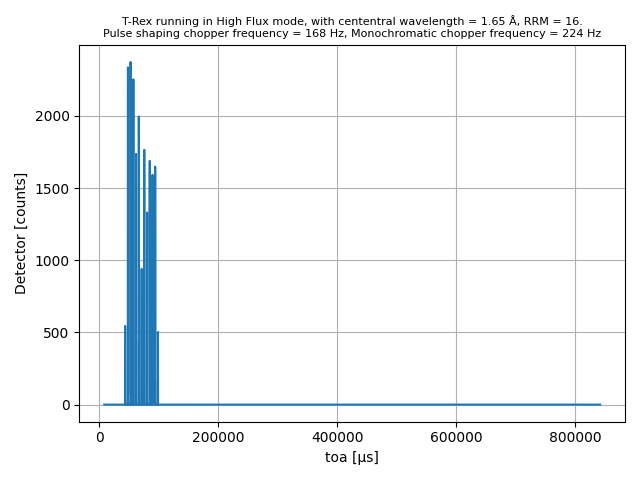

In [7]:
%matplotlib widget
import scipp as sc
from trex.instrument import Instrument
from trex.components.source import Source
import plopp as pp
import matplotlib.pylab as plt

central_wavelength = 1.65 * sc.Unit("Å")
mode = "High Flux"  # Chopper mode
rrm = 16
T_OFFSET = sc.scalar(1.7, unit="ms")

trex = Instrument(central_wavelength, rrm, mode, T_OFFSET)
trex.source = Source(
    facility="ess",
    neutrons=10_000_000,
)
wavelength_requested = trex.calculate_incoming_wavelength()
res = trex.run()

hist_det = res.detectors["Detector"].data.hist(toa=5_000)


fig, ax = plt.subplots()
p = pp.plot({"Detector": hist_det}, grid=True, ax=ax)  # type: ignore
ax.set_title(str(trex), fontsize=8)
fig.tight_layout()

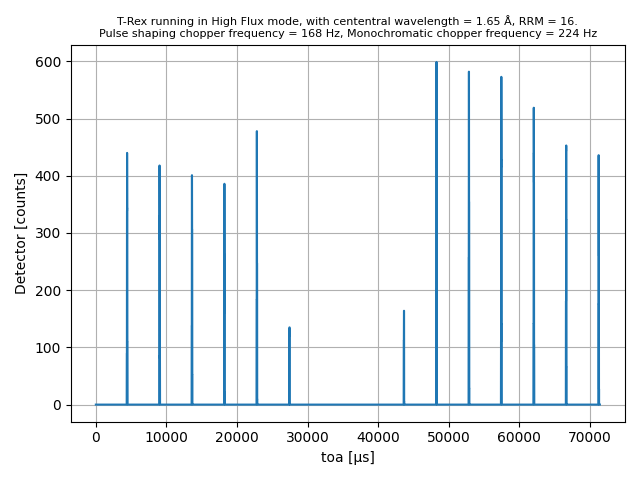

In [8]:
trex.wrap_frame(res)
hist_det = res.detectors["Detector"].data.hist(toa=5_000)

fig, ax = plt.subplots()
p = pp.plot({"Detector": hist_det}, grid=True, ax=ax)  # type: ignore
ax.set_title(str(trex), fontsize=8)
fig.tight_layout()

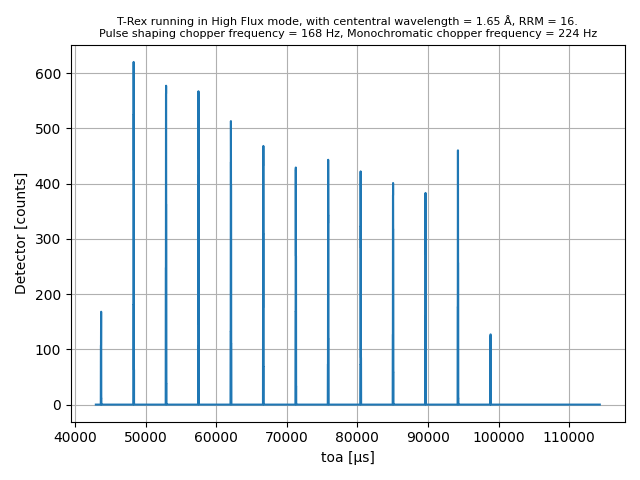

In [9]:
params = trex.unwrap_frame(res, ei_ef_ratio=0.0)
reduced_list = trex.toa_to_energy(res, *params)
hist_det = res.detectors["Detector"].data.hist(toa=5_000)

fig, ax = plt.subplots()
p = pp.plot({"Detector": hist_det}, grid=True, ax=ax)  # type: ignore
ax.set_title(str(trex), fontsize=8)
fig.tight_layout()

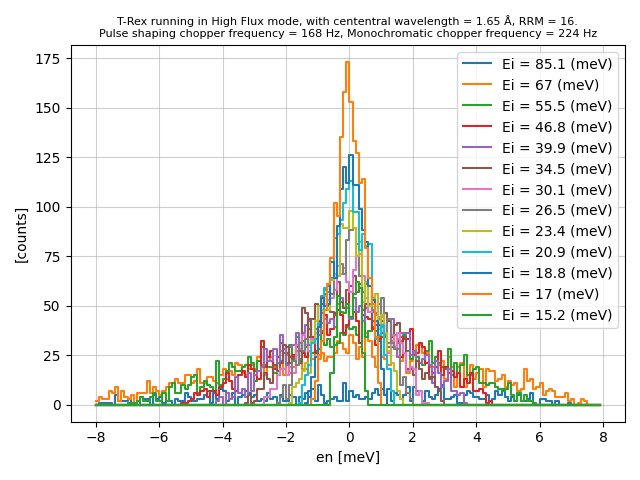

In [10]:
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        en=sc.arange("en", -8, 8, 0.1, unit="meV")
    )
    for reduced in reduced_list
}

fig, ax = plt.subplots()
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex), fontsize=8)
ax.grid(alpha=0.6)
fig.tight_layout()

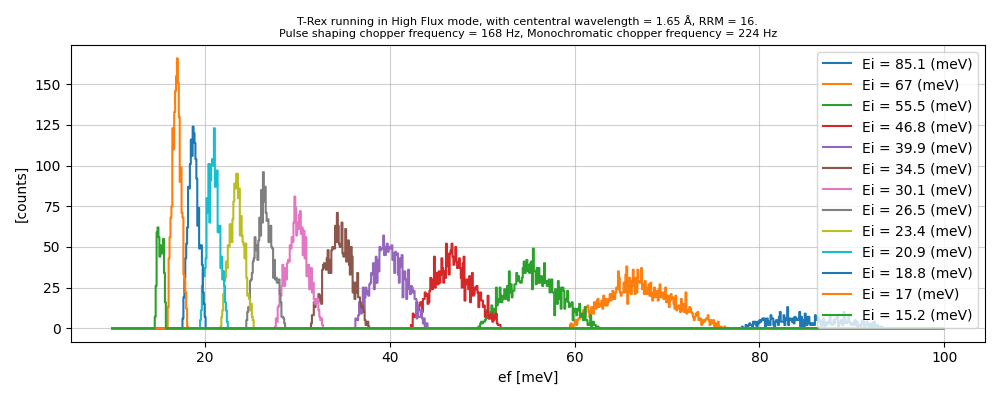

In [11]:
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        ef=sc.arange("ef", 10, 100, 0.1, unit="meV")
    )
    for reduced in reduced_list
}

fig, ax = plt.subplots(figsize=(10, 4))
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex), fontsize=8)
ax.grid(alpha=0.6)
fig.tight_layout()

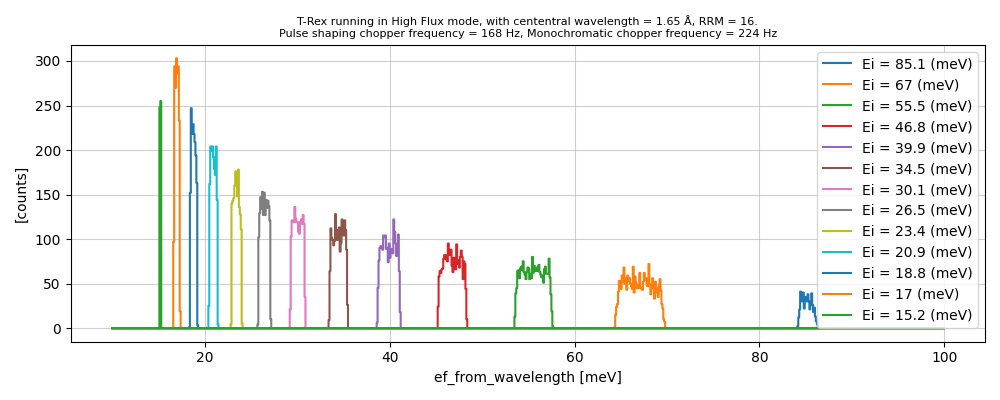

In [12]:
import tof

reduced_list_new = []
for reduced in reduced_list:
    ef_wavelength = tof.utils.wavelength_to_energy(reduced.coords["wavelength"])
    reduced_list_new.append(
        reduced.assign_coords({"ef_from_wavelength": ef_wavelength})
    )

hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        ef_from_wavelength=sc.arange("ef_from_wavelength", 10, 100, 0.1, unit="meV")
    )
    for reduced in reduced_list_new
}

fig, ax = plt.subplots(figsize=(10, 4))
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex), fontsize=8)
ax.grid(alpha=0.6)
fig.tight_layout()